In [1]:
import pandas as pd
import numpy as np
import re #regul expression
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

In [2]:
nltk.download('pukt')
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Error loading pukt: Package 'pukt' not found in index
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
data = {
    "Review" : [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product.Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}
df = pd.DataFrame(data)

In [6]:
print("Customer Review Dtatset")
print(df.head())

Customer Review Dtatset
                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                   Amazing product.Worth the money.


In [8]:
stop_words = set(stopwords.words('english'))
def clean_text(text):

   #convert to lowercase
   text = text.lower()

   #remove special characters and punctuation
   text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  #sub---substitue

   #Tokenization
   words = word_tokenize(text)   #word tokenize

   #remove stop words
   words = [word for word in words if word not in stop_words]  #List comprehension
   #LIST COMPREHENSION---IF THE WORD IS THERE OK IF NOT ADD THOSE WORDS IN NEXT STEP

   #Join words again
   cleaned_text = " ".join(words)

   return cleaned_text

   #Apply cleaning function
df['cleaned_Review'] = df['Review'].apply(clean_text)

print("\n Cleaned Review Dataset") #printing
print(df[['Review', 'cleaned_Review']])


 Cleaned Review Dataset
                                              Review  \
0  The product quality is excellent and delivery ...   
1       Very bad packaging and the item was damaged.   
2       Customer service was helpful and responsive.   
3  The delivery was delayed and support team did ...   
4                   Amazing product.Worth the money.   
5      Poor quality product and terrible experience.   
6                  Fast shipping and good packaging.   
7        The product stopped working after two days.   
8               Excellent service and great quality.   
9            Late delivery and bad customer support.   

                             cleaned_Review  
0   product quality excellent delivery fast  
1                bad packaging item damaged  
2       customer service helpful responsive  
3     delivery delayed support team respond  
4                amazing productworth money  
5  poor quality product terrible experience  
6              fast shipping good pa

In [9]:
stop_words = set(stopwords.words('english'))
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [19]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
    score = sia.polarity_scores(review)
    compound = score['compound']
    if compound >= 0.05:
       return "Positive"
    elif compound <= 0.05:
       return "Negative"
    else:
       return "Neutral"
       df['Sentiment'] = df['cleaned_Review'].apply(analyze_sentiment)
       print("\nSentiment Analysis Result")
       print(df[['Review', 'Sentiment']])

In [21]:
print("\n Sentiment Analysis")
df['Sentiment'] = df['cleaned_Review'].apply(analyze_sentiment)
print(df[['Review', 'Sentiment']])


 Sentiment Analysis
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                   Amazing product.Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


In [18]:
all_words = ' '.join(df['cleaned_Review'])
word_list = all_words.split()
word_freq = Counter(word_list)
print("\nTop 10 Commen Keyword")
print(word_freq.most_common(10))



Top 10 Commen Keyword
[('product', 3), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [24]:
negative_reviews = df[df['Sentiment'] == 'Negative']
negative_words = ' '.join(negative_reviews['cleaned_Review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)
print("\nMoat Common Complaint Keywords")
print(complaint_freq.most_common(10))


Moat Common Complaint Keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


In [25]:
sentiment_counts=df['Sentiment'].value_counts()  # it will category count
sentiment_counts

,count
Sentiment,
Positive,6
Negative,4


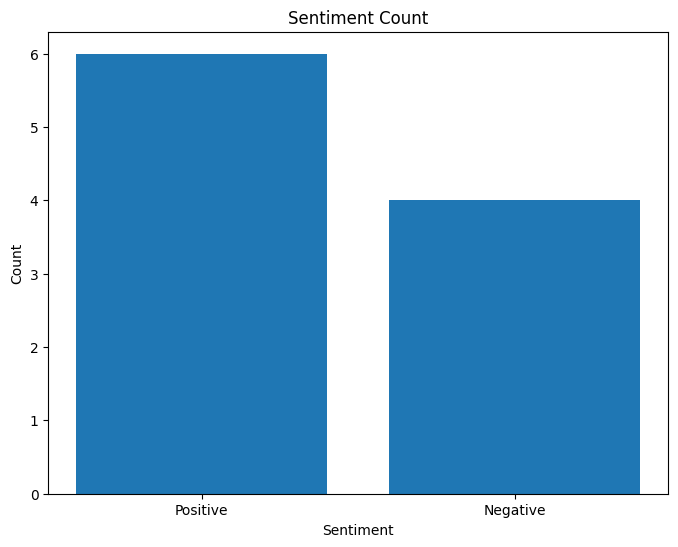

In [26]:
sentiment_counts=df['Sentiment'].value_counts()  # it will category count

plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Count')
plt.show()

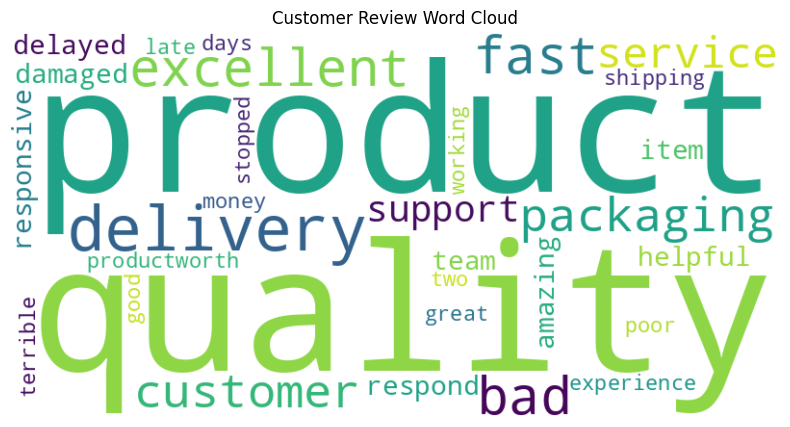

In [29]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Customer Review Word Cloud")
plt.show()

In [30]:
print("\nBusiness Insights")
print("-------------------------------")

positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])

print("Total Positive Reviews :", positive_count)
print("Total Negative Reviews :", negative_count)

print("\nCommon Postive Areas:")
print(" Product quality")
print(" Fast delivery")
print(". Good customer service")


print("\nCommon Customer Complaints:")
print(".Delayed delivery")
print(".Damaged products")
print(". Poor support response")
print(". Product malfunction issues ")

print("\nRecommendation:")
print("The company should improve delivery management,")
print("strengthen packaging quality, and enhance customer support response time.")


Business Insights
-------------------------------
Total Positive Reviews : 6
Total Negative Reviews : 4

Common Postive Areas:
 Product quality
 Fast delivery
. Good customer service

Common Customer Complaints:
.Delayed delivery
.Damaged products
. Poor support response
. Product malfunction issues 

Recommendation:
The company should improve delivery management,
strengthen packaging quality, and enhance customer support response time.
